In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
connect = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
    SELECT timestamp
    FROM checker
    WHERE uid LIKE "user_%"
"""
df = pd.read_sql(query, connect, parse_dates=['timestamp'])

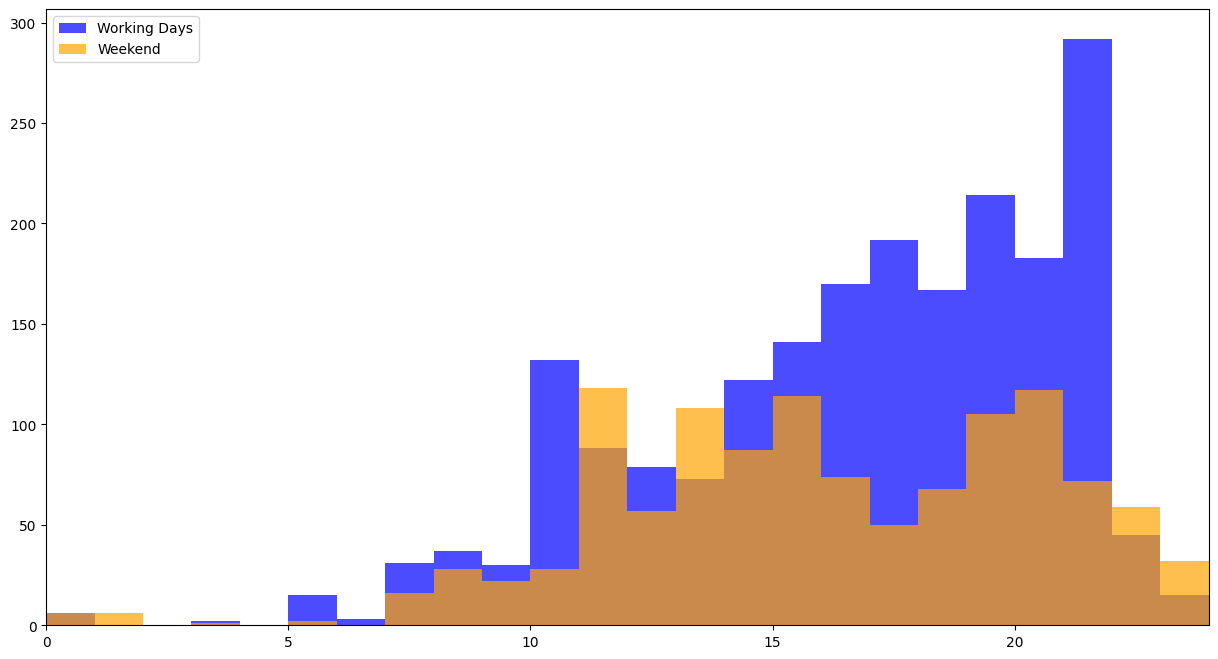

In [13]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

working_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekend = ['Saturday', 'Sunday']

working_day_data = df[df['day_of_week'].isin(working_days)]
weekend_data = df[df['day_of_week'].isin(weekend)]

working_day_counts = working_day_data.groupby('hour').size()
weekend_counts = weekend_data.groupby('hour').size()

plt.figure(figsize=(15,8))

plt.hist(working_day_counts.index, 
         weights=working_day_counts.values, 
         bins=24, 
         range=(0, 24), 
         alpha=0.7, 
         label='Working Days', 
         color='blue')

plt.hist(weekend_counts.index, 
         weights=weekend_counts.values, 
         bins=24, 
         alpha=0.7, 
         range=(0, 24),
         label='Weekend', 
         color='orange')
plt.gca().margins(x=0)
plt.legend()
plt.show()

In [14]:
print(working_day_data.shape)
weekend_data.shape

(2037, 3)


(1170, 3)

In [15]:
connect.close()

## Ответ: 11, 13, 22, 23